In [1]:
import seaborn as sns
import numpy as np

# query

Provide the python code for computing Moran’s I metric of the data with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.

# old

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally, Moran's I requires a spatial dataset. Since pbmc3k isn't inherently spatial,
# we fabricate some spatial coordinates for demonstration purposes. In real scenarios,
# you would use actual spatial coordinates associated with the cells.
np.random.seed(42)
adata.obs['x_coord'] = np.random.rand(adata.n_obs)
adata.obs['y_coord'] = np.random.rand(adata.n_obs)

# Create a spatial neighbors graph, assuming it's based on the mock coordinates
sc.pp.neighbors(adata, use_rep='X_pca', key_added='spatial_neighbors', n_neighbors=10)
sc.tl.draw_graph(adata, key_added='spatial_neighbors_draw_graph')

# Choose a gene to calculate Moran's I statistic, for instance 'CST3'
gene_expression = adata[:, 'CST3'].X
if scipy.sparse.issparse(gene_expression):
    gene_expression = gene_expression.toarray().flatten()

# Since spatial data like coordinates are needed (and we've fabricated some), we calculate Moran's I
import geopandas as gpd
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Create a GeoDataFrame for using spatial analysis tools
gdf = gpd.GeoDataFrame(adata.obs, geometry=gpd.points_from_xy(adata.obs.x_coord, adata.obs.y_coord))

# Create a spatial weights matrix using a threshold distance
# Note: This value of distance (like 0.2 here) should ideally be based on your dataset's actual spatial context.
w = DistanceBand.from_dataframe(gdf, threshold=0.2, binary=True, silence_warnings=True)

# Compute Moran's I
moran_i = Moran(gene_expression, w)
print('Moran’s I:', moran_i.I, 'P-value:', moran_i.p_sim)

# Visualization of the gene expression with the coordinates to visualize possible spatial autocorrelation
plt.scatter(adata.obs['x_coord'], adata.obs['y_coord'], c=gene_expression, cmap='viridis', s=50)
plt.colorbar(label='Expression level of CST3')
plt.title('Spatial Distribution of CST3 Expression')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


TypeError: 'key_added' is an invalid keyword argument for this function

### from now, codes run with fa2-modified installed rather than fr

### note that, the original report mentioned that this response uses moran's I outside scanpy. Although this problem is minor, in the new report scanpy's moran's I is leveraged. I suppose this is because the randomness of llm. This also reminds me of the controllability of bioma.

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally, Moran's I requires a spatial dataset. Since pbmc3k isn't inherently spatial,
# we fabricate some spatial coordinates for demonstration purposes. In real scenarios,
# you would use actual spatial coordinates associated with the cells.
np.random.seed(42)
adata.obs['x_coord'] = np.random.rand(adata.n_obs)
adata.obs['y_coord'] = np.random.rand(adata.n_obs)


In [4]:
# Create a spatial neighbors graph, assuming it's based on the mock coordinates
sc.pp.neighbors(adata, use_rep='X_pca', key_added='spatial_neighbors', n_neighbors=10)

In [7]:
sc.tl.draw_graph(adata, key_added='spatial_neighbors_draw_graph')

In [10]:
sc.tl.draw_graph(adata, hahahahtestwtf=1)

### damn! after fa2-modified is installed, key_added problem disappears! and any args works well!! WTF???

### ok after checking source codes I see: fa and fr layout will call different functions, where fr layout feed all input args into igraph.layout, leading to the above bug; and fa layout only selects necessary args from input args, so no such bugs happen.

### this gives me an idea: if problems of such args occur, we can simply remove them and leave it default or refer to external codes for supplementation. In the case of fr layout, removing it will resolve the bug.

In [11]:
# Choose a gene to calculate Moran's I statistic, for instance 'CST3'
gene_expression = adata[:, 'CST3'].X
if scipy.sparse.issparse(gene_expression):
    gene_expression = gene_expression.toarray().flatten()

NameError: name 'scipy' is not defined

### this can be easily resolved by feed warnings into llm. but i think, this process is not needed to be shown to users. too verbose.

### note that this gene 'CST3' is also coincidentally exists in the data. gpt4 cannot access data.

In [14]:
import scipy
# Choose a gene to calculate Moran's I statistic, for instance 'CST3'
gene_expression = adata[:, 'CST3'].X
if scipy.sparse.issparse(gene_expression):
    gene_expression = gene_expression.toarray().flatten()

In [15]:
# Since spatial data like coordinates are needed (and we've fabricated some), we calculate Moran's I
import geopandas as gpd
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Create a GeoDataFrame for using spatial analysis tools
gdf = gpd.GeoDataFrame(adata.obs, geometry=gpd.points_from_xy(adata.obs.x_coord, adata.obs.y_coord))

ModuleNotFoundError: No module named 'libpysal'

### easily resolved by feeding ... (same as above)

In [16]:
# Since spatial data like coordinates are needed (and we've fabricated some), we calculate Moran's I
import geopandas as gpd
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Create a GeoDataFrame for using spatial analysis tools
gdf = gpd.GeoDataFrame(adata.obs, geometry=gpd.points_from_xy(adata.obs.x_coord, adata.obs.y_coord))

ModuleNotFoundError: No module named 'esda'

In [17]:
# Since spatial data like coordinates are needed (and we've fabricated some), we calculate Moran's I
import geopandas as gpd
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Create a GeoDataFrame for using spatial analysis tools
gdf = gpd.GeoDataFrame(adata.obs, geometry=gpd.points_from_xy(adata.obs.x_coord, adata.obs.y_coord))

In [18]:
w = DistanceBand.from_dataframe(gdf, threshold=0.2, binary=True, silence_warnings=True)

# Compute Moran's I
moran_i = Moran(gene_expression, w)
print('Moran’s I:', moran_i.I, 'P-value:', moran_i.p_sim)

Moran’s I: 0.0010320352404177054 P-value: 0.183


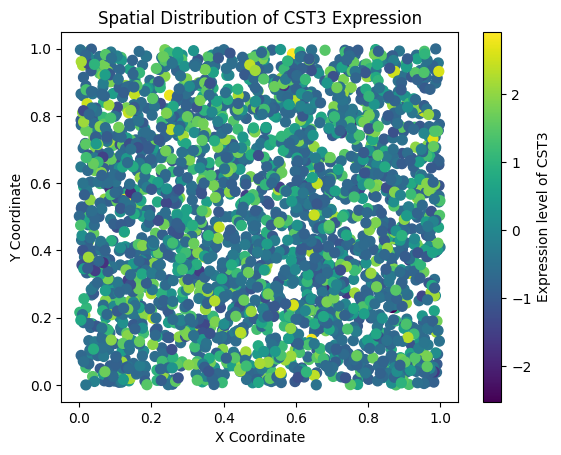

In [19]:
# Visualization of the gene expression with the coordinates to visualize possible spatial autocorrelation
plt.scatter(adata.obs['x_coord'], adata.obs['y_coord'], c=gene_expression, cmap='viridis', s=50)
plt.colorbar(label='Expression level of CST3')
plt.title('Spatial Distribution of CST3 Expression')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# new

In [20]:
import scanpy as sc

# Load an example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally preprocessing would be here, but pbmc3k_processed is already preprocessed
# Ensuring principal component analysis is done
if 'X_pca' not in adata.obsm.keys():
    sc.tl.pca(adata)

# Compute a neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute Moran's I for some genes - here using example genes
# Select a few genes for demonstration
example_genes = adata.var_names[:5]

# Compute Moran's I for these genes
morans_i_results = {}
for gene in example_genes:
    adata.obs[gene] = adata[:, gene].X.flatten()
    morans_i = sc.metrics.morans_i(adata, var_names=gene)
    morans_i_results[gene] = morans_i

# Print the results
for gene, result in morans_i_results.items():
    print(f"Moran's I for {gene}: {result['I']:.4f}")


TypeError: morans_i() got an unexpected keyword argument 'var_names'

### morans_i works in this way: it computes the local similarity between each gene and its neighboring two genes. So it returns a 1-D array storing such values for all genes. it seems that gpt4 understands its function and goal even though they are actually very vague in doc (how it understands if doc is even so vague?), but it doesn't really know how it works and how to use it. Maybe because doc is too vague, too few examples (also in the doc)...

### in this case, some solutions to boost biomania, 1) feed doc. I won't think it can really work since doc is already too vague. we can try use doc as in-context example and see how gpt4 performs. 2) reinforcement learning (similar to online data generation). gpt4 can generate the simplest form of API calling with as few args as possible, running it, getting results, complicating a bit API calling based on instruction of doc, running it, getting results, ... gpt4 may be able to understand how this API works during this learning sequence.

### I like the example 2), quite interesting!

### actually this problem is quite problematic

In [34]:
import scanpy as sc

# Load an example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally preprocessing would be here, but pbmc3k_processed is already preprocessed
# Ensuring principal component analysis is done
if 'X_pca' not in adata.obsm.keys():
    sc.tl.pca(adata)

# Compute a neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute Moran's I for these genes  
# Jiahang: I remove many codes since too achieve the same goal, this one line is enough.
morans_i = sc.metrics.morans_i(adata)

print(morans_i)


[0.14834098 0.03383912 0.00788571 ... 0.00068832 0.09485227 0.04056926]
